# English-Hindi Domain Specific(Legal) Translator using Transformer
# Project Overview
This project implements an English to Hindi legal translation system using a Transformer based neural machine translation model.

Pipeline:
1.Dataset loading
2.Data preprocessing
3.Tokenization
4.Transformer architecture
5.Model training
6.Translation inference

In [42]:

#Import Liberaries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import sentencepiece as spm
import os
import re

from sklearn.model_selection import train_test_split

In [43]:
#Dataset Loading
DATA_PATH="data/English-Hindi-Legal-corpus.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (25000, 4)


,id,english,hindi,category
0,1,The High Court of Calcutta directed Mahesh Pat...,कलकत्ता उच्च न्यायालय ने महेश पटेल को गीता पटे...,Family Law
1,2,The winding-up petition against Vishal Infrast...,"रु. 90,000 के अभुगतान के लिए विशाल इंफ्रास्ट्र...",Corporate Law
2,3,The High Court of Calcutta dismissed the appli...,कलकत्ता उच्च न्यायालय ने पोषणीयता के अभाव में ...,Civil Law
3,4,The victim Ramesh Kumar recorded her statement...,पीड़िता रमेश कुमार ने मजिस्ट्रेट के समक्ष भारत...,Criminal Law
4,5,The Supreme Court of India granted custody of ...,भारत के उच्चतम न्यायालय ने कविता रानी को मिलन ...,Family Law


In [44]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate pairs:")
print(df.duplicated(subset=["english","hindi"]).sum())

Missing values:
id          0
english     0
hindi       0
category    0
dtype: int64

Duplicate pairs:
0


# Exploratory Data Analysis(EDA)

In [45]:
print("Total sentence pairs:", len(df))

print("\nCategories:")
print(df["category"].value_counts())

print("\nEnglish sentence examples:")
display(df["english"].head())

print("\nHindi sentence examples:")
display(df["hindi"].head())

Total sentence pairs: 25000

Categories:
category
Criminal Law                 4000
Contract Law                 3500
Civil Law                    3000
Constitutional Law           3000
General Legal Procedure      3000
Property Law                 2500
Corporate Law                2000
Family Law                   1500
Labour Law                   1500
Intellectual Property Law    1000
Name: count, dtype: int64

English sentence examples:


0    The High Court of Calcutta directed Mahesh Pat...
1    The winding-up petition against Vishal Infrast...
2    The High Court of Calcutta dismissed the appli...
3    The victim Ramesh Kumar recorded her statement...
4    The Supreme Court of India granted custody of ...
Name: english, dtype: str


Hindi sentence examples:


0    कलकत्ता उच्च न्यायालय ने महेश पटेल को गीता पटे...
1    रु. 90,000 के अभुगतान के लिए विशाल इंफ्रास्ट्र...
2    कलकत्ता उच्च न्यायालय ने पोषणीयता के अभाव में ...
3    पीड़िता रमेश कुमार ने मजिस्ट्रेट के समक्ष भारत...
4    भारत के उच्चतम न्यायालय ने कविता रानी को मिलन ...
Name: hindi, dtype: str

In [46]:
df["english_length"]=df["english"].apply(
    lambda x:len(str(x).split())
)

df["hindi_length"] =df["hindi"].apply(
    lambda x:len(str(x).split())
)


print("Average English sentence length:",
      df["english_length"].mean())

print("Average Hindi sentence length:",
      df["hindi_length"].mean())

df[["english_length","hindi_length"]].describe()

Average English sentence length: 19.95948
Average Hindi sentence length: 21.08436


,english_length,hindi_length
count,25000.000000,25000.000000
mean,19.959480,21.084360
std,3.619431,3.865571
min,13.000000,14.000000
25%,17.000000,18.000000
50%,19.000000,20.000000
75%,23.000000,24.000000
max,33.000000,31.000000


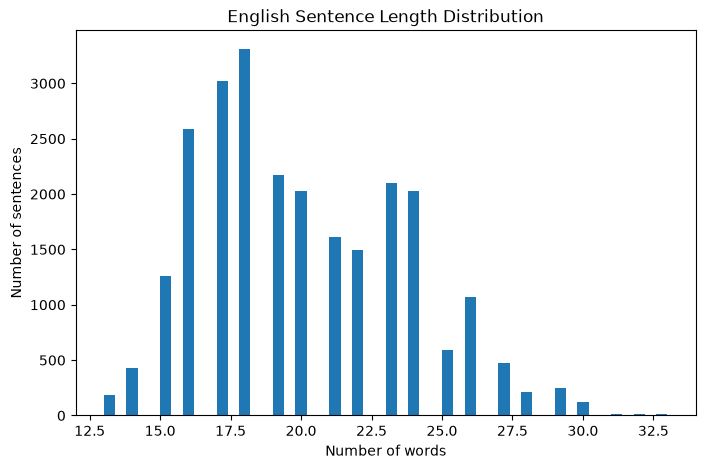

In [47]:
plt.figure(figsize=(8,5))

plt.hist(
    df["english_length"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("English Sentence Length Distribution")

plt.show()

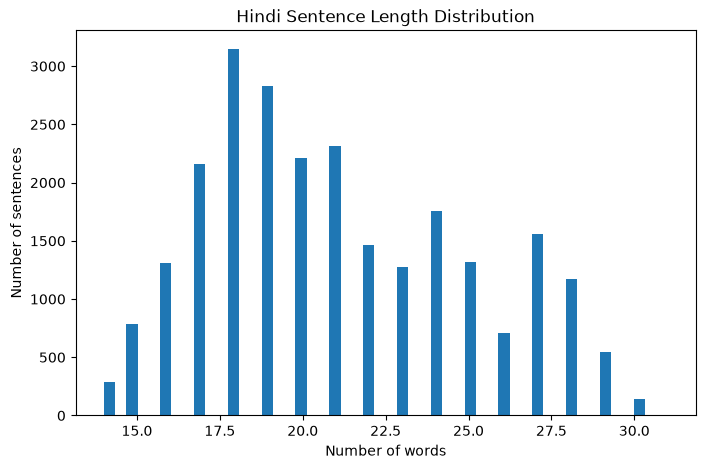

In [48]:
plt.figure(figsize=(8,5))
plt.hist(
    df["hindi_length"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("Hindi Sentence Length Distribution")

plt.show()

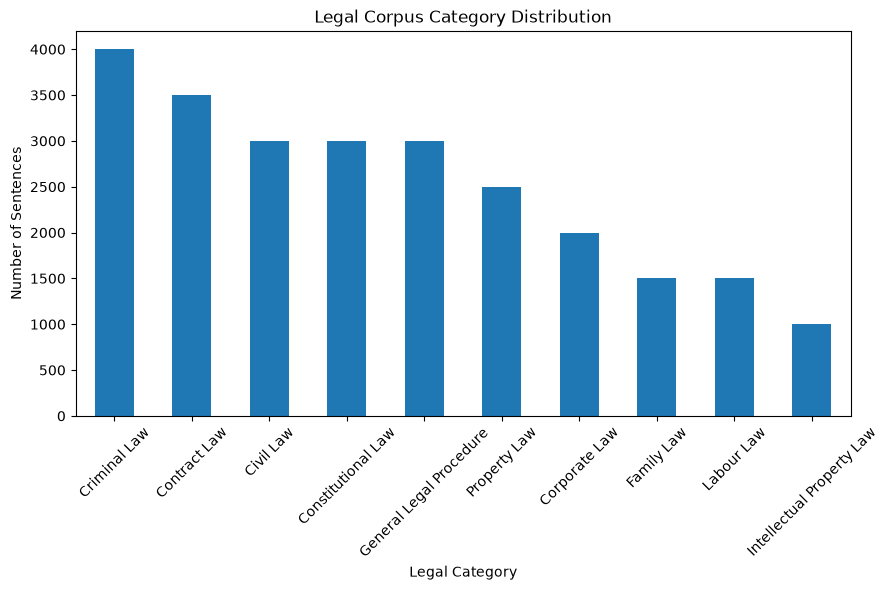

In [49]:
plt.figure(figsize=(10,5))

df["category"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Legal Category")
plt.ylabel("Number of Sentences")
plt.title("Legal Corpus Category Distribution")

plt.xticks(rotation=45)

plt.show()

# Text Preprocessing and Tokenization

In [50]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)#remove extra spaces
    text = text.strip()#remove trailing spaces
    return text

df["english"] = df["english"].apply(clean_text)
df["hindi"] = df["hindi"].apply(clean_text)

df.head()

,id,english,hindi,category,english_length,hindi_length
0,1,The High Court of Calcutta directed Mahesh Pat...,कलकत्ता उच्च न्यायालय ने महेश पटेल को गीता पटे...,Family Law,18,20
1,2,The winding-up petition against Vishal Infrast...,"रु. 90,000 के अभुगतान के लिए विशाल इंफ्रास्ट्र...",Corporate Law,20,22
2,3,The High Court of Calcutta dismissed the appli...,कलकत्ता उच्च न्यायालय ने पोषणीयता के अभाव में ...,Civil Law,22,21
3,4,The victim Ramesh Kumar recorded her statement...,पीड़िता रमेश कुमार ने मजिस्ट्रेट के समक्ष भारत...,Criminal Law,18,19
4,5,The Supreme Court of India granted custody of ...,भारत के उच्चतम न्यायालय ने कविता रानी को मिलन ...,Family Law,21,22


In [52]:
train_df,val_df = train_test_split(df,test_size=0.1,random_state=42)
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 22500
Validation samples: 2500


# SentencePiece Tokenization

In [53]:
#English corpus
with open("english_train.txt", "w", encoding="utf-8") as f:
    for sentence in train_df["english"]:
        f.write(sentence + "\n")

# Hindi corpus
with open("hindi_train.txt", "w", encoding="utf-8") as f:
    for sentence in train_df["hindi"]:
        f.write(sentence + "\n")


print("Text files created")

Text files created


In [54]:
spm.SentencePieceTrainer.train(
    input="english_train.txt",
    model_prefix="english_tokenizer",
    vocab_size=4000,
    character_coverage=1.0,
    model_type="bpe"
)

print("English tokenizer created")

English tokenizer created


In [55]:
spm.SentencePieceTrainer.train(
    input="hindi_train.txt",
    model_prefix="hindi_tokenizer",
    vocab_size=4000,
    character_coverage=1.0,
    model_type="bpe"
)

print("Hindi tokenizer created")

Hindi tokenizer created


# Creating PyTorch Dataset

In [56]:
english_sp = spm.SentencePieceProcessor()
english_sp.load("english_tokenizer.model")

hindi_sp = spm.SentencePieceProcessor()
hindi_sp.load("hindi_tokenizer.model")


print("English vocabulary:", english_sp.get_piece_size())
print("Hindi vocabulary:", hindi_sp.get_piece_size())

English vocabulary: 4000
Hindi vocabulary: 4000


In [57]:
sample = train_df.iloc[0]

print("English:")
print(sample["english"])

print("\nTokens:")
print(english_sp.encode(sample["english"]))

print("\nHindi:")
print(sample["hindi"])

print("\nTokens:")
print(hindi_sp.encode(sample["hindi"]))

English:
Manju Chauhan moved an application for anticipatory bail apprehending arrest under Section 302 of the Indian Penal Code.

Tokens:
[509, 285, 1638, 165, 392, 72, 1098, 682, 974, 1075, 59, 73, 1857, 9, 12, 262, 378, 175, 3953]

Hindi:
भारतीय दंड संहिता की धारा 302 के अंतर्गत गिरफ्तारी की आशंका से मंजू चौहान ने अग्रिम जमानत हेतु आवेदन प्रस्तुत किया।

Tokens:
[251, 218, 178, 16, 70, 1658, 9, 51, 1474, 16, 888, 75, 465, 267, 17, 1473, 623, 79, 375, 275, 35, 3953]


In [58]:
from torch.utils.data import Dataset

class LegalTranslationDataset(Dataset):
    def __init__(self, dataframe, english_tokenizer, hindi_tokenizer, max_length=50):
        self.data = dataframe.reset_index(drop=True)

        self.en_tokenizer = english_tokenizer
        self.hi_tokenizer = hindi_tokenizer

        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        row = self.data.iloc[index]

        english = row["english"]
        hindi = row["hindi"]

        en_tokens = self.en_tokenizer.encode(
            english,
            out_type=int
        )
        hi_tokens = self.hi_tokenizer.encode(
            hindi,
            out_type=int
        )
        # limit length
        en_tokens = en_tokens[:self.max_length]
        hi_tokens = hi_tokens[:self.max_length]

        return {
            "source": torch.tensor(en_tokens),
            "target": torch.tensor(hi_tokens)
        }

In [66]:
train_dataset = LegalTranslationDataset(
    train_df,
    english_sp,
    hindi_sp
)
val_dataset = LegalTranslationDataset(
    val_df,
    english_sp,
    hindi_sp
)

train_dataset = torch.utils.data.Subset(
    train_dataset,
    range(5000)
)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 5000
Validation samples: 2500


# Transformer Model Architecture

In [67]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    source = [item["source"] for item in batch]
    target = [item["target"] for item in batch]
    return source, target

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)
print("DataLoaders ready")

DataLoaders ready


In [68]:
import math
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(
            0,
            max_len,
            dtype=torch.float
        ).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            *
            (-math.log(10000.0) / d_model)
        )
        pe[:,0::2] = torch.sin(
            position * div_term
        )
        pe[:,1::2] = torch.cos(
            position * div_term
        )
        self.register_buffer(
            "pe",
            pe.unsqueeze(0)
        )
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [69]:
class TransformerTranslator(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=256,
        nhead=8,
        num_layers=3
    ):
        super().__init__()
        self.src_embedding = nn.Embedding(
            src_vocab_size,
            d_model
        )
        self.tgt_embedding = nn.Embedding(
            tgt_vocab_size,
            d_model
        )
        self.position = PositionalEncoding(
            d_model
        )
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(
            d_model,
            tgt_vocab_size
        )
    def forward(self, src, tgt):
        src = self.src_embedding(src)
        tgt = self.tgt_embedding(tgt)
        src = self.position(src)
        tgt = self.position(tgt)
        output = self.transformer(
            src,
            tgt
        )
        return self.fc(output)

# Model Initialization and Training Setup

In [70]:
device = torch.device(
    "cpu"
)
print("Using:", device)

model = TransformerTranslator(
    src_vocab_size=english_sp.get_piece_size(),
    tgt_vocab_size=hindi_sp.get_piece_size(),
    d_model=64,
    nhead=4,
    num_layers=1
)
model = model.to(device)
print("Model created")

Using: cpu
Model created


In [71]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)
print("Training setup ready")

Training setup ready


In [72]:
from torch.nn.utils.rnn import pad_sequence
PAD_ID = 0
def collate_fn(batch):
    source = [
        item["source"]
        for item in batch
    ]
    target = [
        item["target"]
        for item in batch
    ]
    source = pad_sequence(
        source,
        batch_first=True,
        padding_value=PAD_ID
    )
    target = pad_sequence(
        target,
        batch_first=True,
        padding_value=PAD_ID
    )
    return source, target

In [73]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)
print("Updated loaders ready")

Updated loaders ready


# Training the Transformer Model

In [74]:
epochs = 2

model.train()

for epoch in range(epochs):
    total_loss = 0
    for source, target in train_loader:
        source = source.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        # Decoder input
        target_input = target[:, :-1]
        # Expected output
        target_output = target[:, 1:]
        output = model(
            source,
            target_input
        )
        loss = criterion(
            output.reshape(-1, output.size(-1)),
            target_output.reshape(-1)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(
        f"Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}"
    )

Epoch 1/2 Loss: 7.0233
Epoch 2/2 Loss: 5.9436


In [75]:
os.makedirs("models",exist_ok=True)
torch.save(
    model.state_dict(),
    "models/legal_transformer.pt"
)
print("Model saved")

Model saved


# Inference Pipeline

In [76]:
model.eval()

print("Model ready for inference")

Model ready for inference


In [81]:
def translate_sentence(sentence, max_length=50):
    model.eval()
    # Encode English input
    source_tokens = english_sp.encode(
        sentence,
        out_type=int
    )
    source = torch.tensor(
        source_tokens
    ).unsqueeze(0).to(device)
    # Start decoder with BOS token
    bos_token = hindi_sp.bos_id()
    if bos_token == -1:
        bos_token = 1
    target = torch.tensor(
        [[bos_token]]
    ).to(device)
    with torch.no_grad():
        for _ in range(max_length):
            output = model(
                source,
                target
            )
            logits = output[:, -1, :]
            logits[:, 0] = -float("inf")

            next_token = logits.argmax(dim=-1)
            target = torch.cat(
                [
                    target,
                    next_token.unsqueeze(0)
                ],
                dim=1
            )
            # stop if EOS generated
            if next_token.item() == hindi_sp.eos_id():
                break
    generated_tokens = target.squeeze().tolist()
    # Remove BOS
    generated_tokens = generated_tokens[1:]
    return hindi_sp.decode(
        generated_tokens
    )

In [82]:
test_sentence = (
    "The Supreme Court granted bail to the accused person."
)
translation = translate_sentence(
    test_sentence
)
print("English:")
print(test_sentence)
print("\nHindi:")
print(translation)

English:
The Supreme Court granted bail to the accused person.

Hindi:
के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के के
